In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csc_matrix
from sksparse.cholmod import cholesky
from scipy.sparse.linalg import spsolve_triangular
import time

In [2]:

def risolvi_e_misura(A_csc, rhs):
    start_time = time.perf_counter()
    
    # 1. Fattorizzazione
    factor = cholesky(A_csc, order="natural")
    
    # ESTRAIAMO L! Sappiamo che è il primo elemento della tupla (indice 0)
    L = factor[0].T 
    
    # 2. Risoluzione matematica in 2 step (poiché L * L^T * u = rhs)
    # Step A: Risolviamo L * y = rhs (sostituzione in avanti)
    y = spsolve_triangular(L, rhs, lower=True)
    
    # Step B: Risolviamo L^T * u = y (sostituzione all'indietro)
    soluzione_u = spsolve_triangular(L.T, y, lower=False)
    
    end_time = time.perf_counter()
    
    return soluzione_u, L, (end_time - start_time)

In [3]:
# 2. IMPOSTAZIONI INIZIALI E LISTE PER IL CONFRONTO
N_values = [32, 64, 128, 256, 512, 1024]

tempi_nat = []
tempi_nd = []
nnz_nat = []
nnz_nd = []


 ANALISI PER N = 32


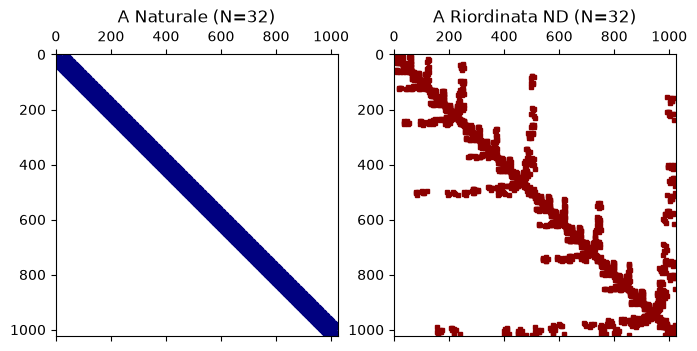

TEMPI -> Naturale: 0.01266s | Riordinato: 0.01024s
NNZ L -> Naturale: 32799 | Riordinato: 15962


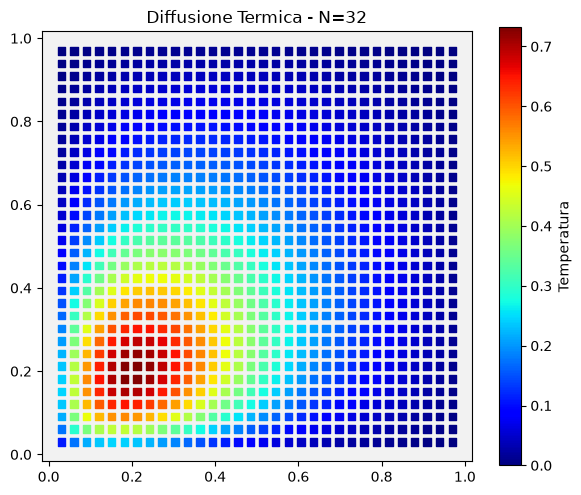


 ANALISI PER N = 64


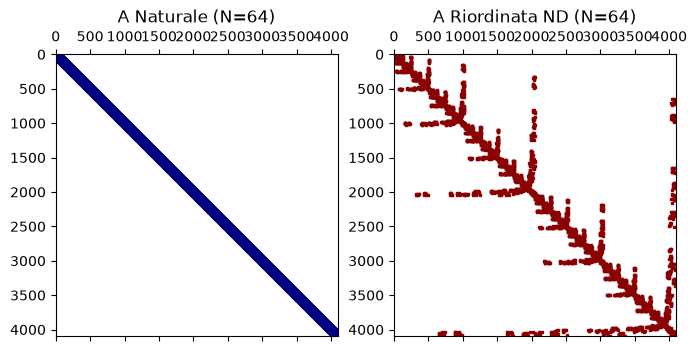

TEMPI -> Naturale: 0.07943s | Riordinato: 0.06337s
NNZ L -> Naturale: 262207 | Riordinato: 88645


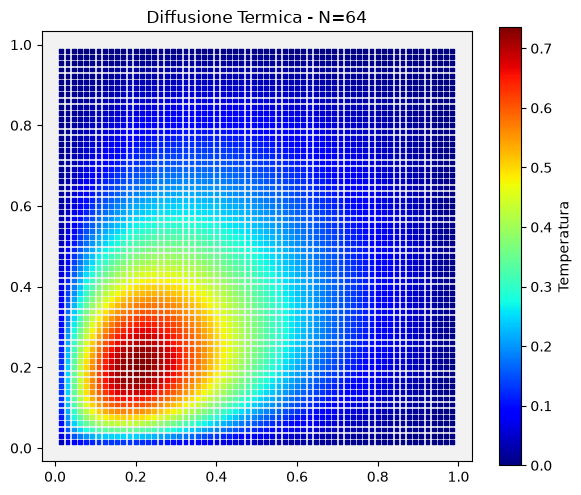


 ANALISI PER N = 128


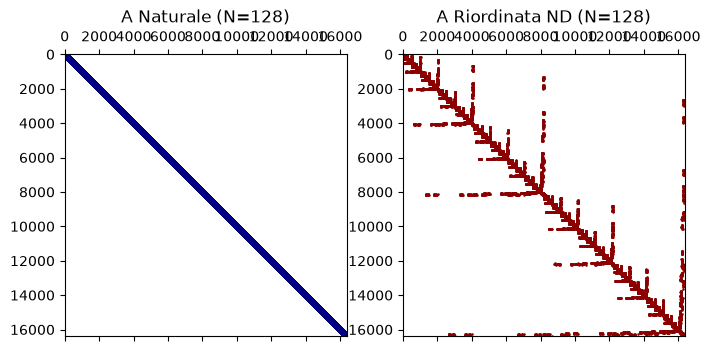

TEMPI -> Naturale: 0.48191s | Riordinato: 0.24528s
NNZ L -> Naturale: 2097279 | Riordinato: 463312


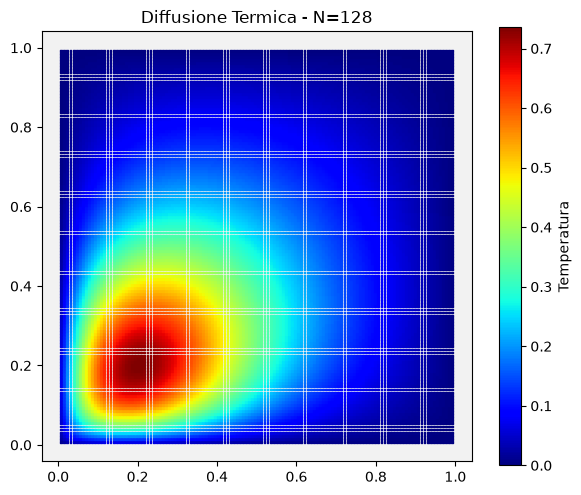


 ANALISI PER N = 256


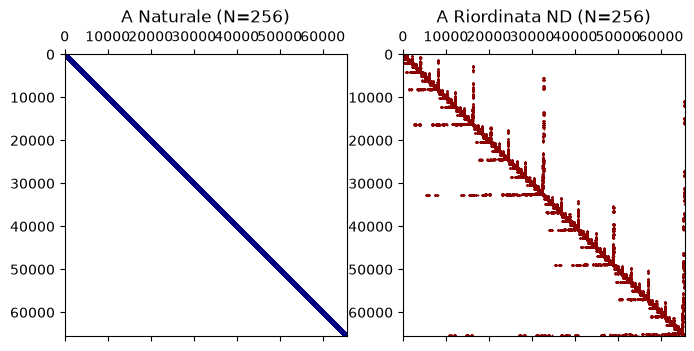

TEMPI -> Naturale: 3.40075s | Riordinato: 0.88365s
NNZ L -> Naturale: 16777471 | Riordinato: 2318762


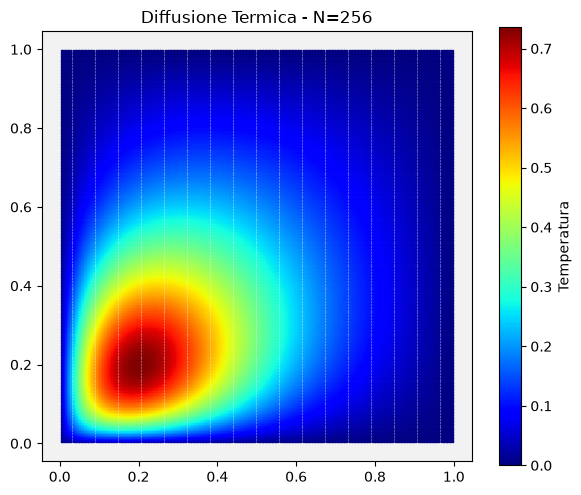


 ANALISI PER N = 512


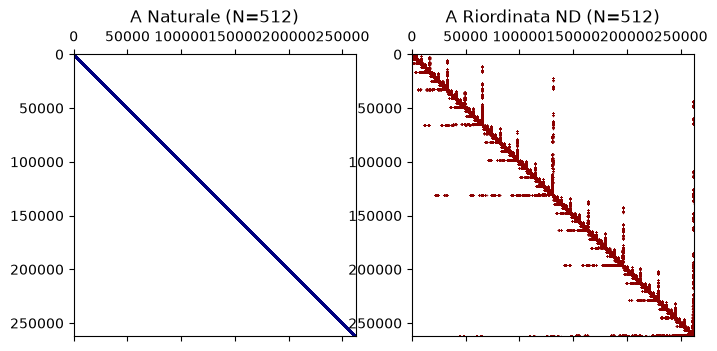

TEMPI -> Naturale: 32.30454s | Riordinato: 3.86508s
NNZ L -> Naturale: 134218239 | Riordinato: 11207067


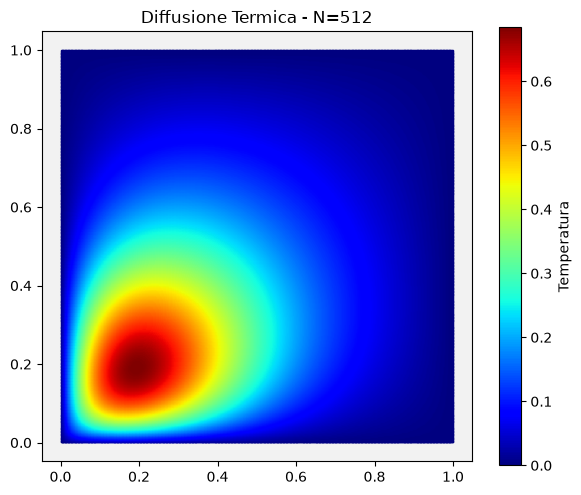


 ANALISI PER N = 1024


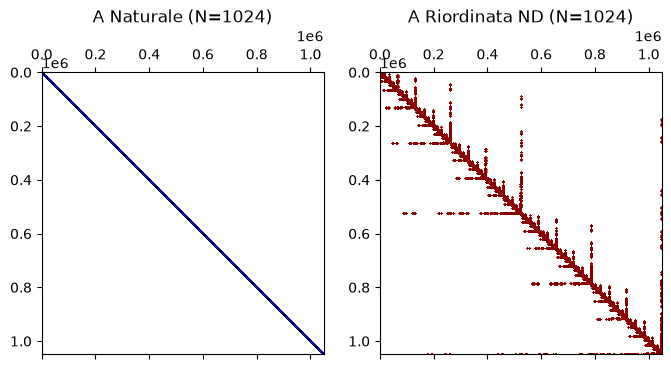

TEMPI -> Naturale: SALTATO (Memoria!) | Riordinato: 18.59000s
NNZ L -> Naturale: SALTATO (Memoria!) | Riordinato: 52721685


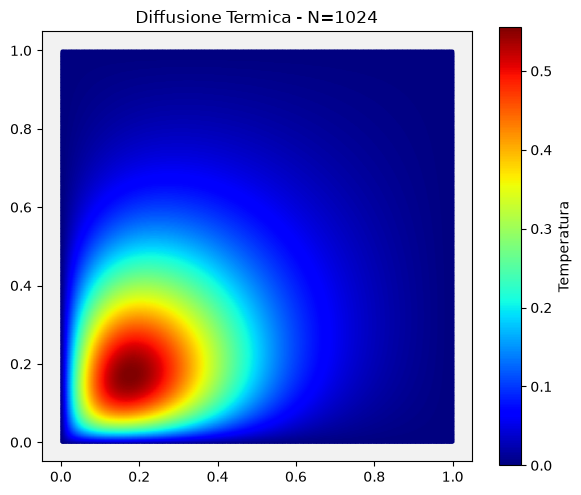

In [4]:
for N in N_values:
    print(f"\n{'='*50}")
    print(f" ANALISI PER N = {N}")
    print(f"{'='*50}")
    
    # 3. CARICAMENTO DATI DALLA CARTELLA "Dati"        
    coords = np.loadtxt(rf"C:\Users\jacop\Desktop\Progetto-informatica\Dati\coords_{N}.txt")
    ordering = np.loadtxt(rf"C:\Users\jacop\Desktop\Progetto-informatica\Dati\ordering_{N}.txt")
    N_nodi = coords.shape[0]
    
    # Dati Naturali
    A_data_nat = np.loadtxt(rf"C:\Users\jacop\Desktop\Progetto-informatica\Dati\A_nat_{N}.txt")
    rhs_nat = np.loadtxt(rf"C:\Users\jacop\Desktop\Progetto-informatica\Dati\rhs_nat_{N}.txt")
    A_csc_nat = csc_matrix((A_data_nat[:, 2], (A_data_nat[:, 0].astype(int), A_data_nat[:, 1].astype(int))), shape=(N_nodi, N_nodi))
    
    # Dati Riordinati (Nested Dissection)
    A_data_nd = np.loadtxt(rf"C:\Users\jacop\Desktop\Progetto-informatica\Dati\A_nd_{N}.txt")
    rhs_nd = np.loadtxt(rf"C:\Users\jacop\Desktop\Progetto-informatica\Dati\rhs_nd_{N}.txt")
    A_csc_nd = csc_matrix((A_data_nd[:, 2], (A_data_nd[:, 0].astype(int), A_data_nd[:, 1].astype(int))), shape=(N_nodi, N_nodi))
     
    # 4. GRAFICO SPY (Confronto visivo delle matrici A)
    spy_marker = max(0.01, 100 / N) 
    
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].spy(A_csc_nat, markersize=spy_marker, color='navy')
    ax[0].set_title(f"A Naturale (N={N})")
    
    ax[1].spy(A_csc_nd, markersize=spy_marker, color='darkred')
    ax[1].set_title(f"A Riordinata ND (N={N})")
    plt.show()

    # 5. RISOLUZIONE E MISURAZIONI (LA GARA)
    
    # Calcoliamo SEMPRE il riordinato (è velocissimo e non consuma RAM)
    sol_nd, L_nd, t_nd = risolvi_e_misura(A_csc_nd, rhs_nd)
    tempi_nd.append(t_nd)
    nnz_nd.append(L_nd.nnz)
    
    # Calcoliamo il naturale SOLO se N è inferiore a 1024
    if N < 1024:
        _, L_nat, t_nat = risolvi_e_misura(A_csc_nat, rhs_nat)
        tempi_nat.append(t_nat)
        nnz_nat.append(L_nat.nnz)
        print(f"TEMPI -> Naturale: {t_nat:.5f}s | Riordinato: {t_nd:.5f}s")
        print(f"NNZ L -> Naturale: {L_nat.nnz} | Riordinato: {L_nd.nnz}")
    else:
        print(f"TEMPI -> Naturale: SALTATO (Memoria!) | Riordinato: {t_nd:.5f}s")
        print(f"NNZ L -> Naturale: SALTATO (Memoria!) | Riordinato: {L_nd.nnz}")
    
    # 6. MAPPATURA E GRAFICO DIFFUSIONE (Uso sol_nd che è più veloce e sempre calcolata)
    
    nuovo_indice = ordering[:, 0].astype(int)
    vecchio_indice = ordering[:, 1].astype(int)
    
    soluzione_naturale = np.zeros(N_nodi)
    soluzione_naturale[vecchio_indice] = sol_nd[nuovo_indice]
    
    X = coords[:, 3]
    Y = coords[:, 4]
    
    plt.figure(figsize=(6, 5))
    ax = plt.gca()
    ax.set_facecolor('#f2f2f2')
    ax.set_aspect('equal')
    
    dim_marker = max(0.5, 30000 / (N**2)) 
    scatter = plt.scatter(X, Y, c=soluzione_naturale, cmap='jet', s=dim_marker, marker='s', vmin=0)
    
    plt.colorbar(scatter, label='Temperatura')
    plt.title(f"Diffusione Termica - N={N}")
    plt.tight_layout()
    plt.show()


 RIEPILOGO FINALE: NATURALE vs RIORDINATO 


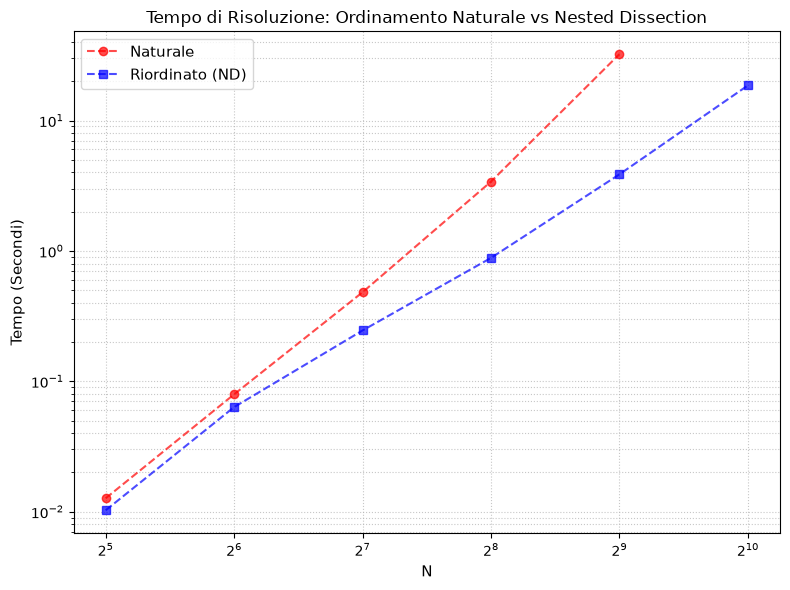

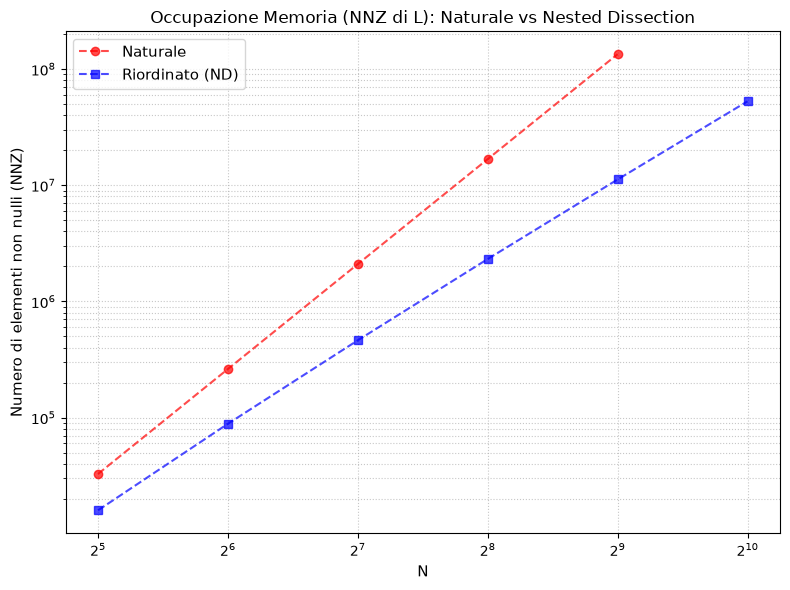

In [7]:
# 7. GRAFICI FINALI COMPARATIVI

print("\n" + "="*50)
print(" RIEPILOGO FINALE: NATURALE vs RIORDINATO ")
print("="*50)

# Allineiamo gli assi X dinamicamente per evitare errori se mancano valori
X_nat = N_values[0:len(tempi_nat)]
X_nd = N_values[0:len(tempi_nd)]


# PRIMO GRAFICO: TEMPI DI RISOLUZIONE

plt.figure(figsize=(8, 6))

plt.plot(X_nat, tempi_nat, label="Naturale", color='red', marker='o', linestyle='--', alpha=0.7, zorder=3)
plt.plot(X_nd, tempi_nd, label="Riordinato (ND)", color='blue', marker='s', linestyle='--', alpha=0.7, zorder=3)

plt.xscale("log", base=2)
plt.yscale("log", base=10)

plt.title("Tempo di Risoluzione: Ordinamento Naturale vs Nested Dissection", fontsize=12)
plt.xlabel("N", fontsize=11)
plt.ylabel("Tempo (Secondi)", fontsize=11)

plt.legend(fontsize=11)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# SECONDO GRAFICO: MEMORIA OCCUPATA (NNZ)

plt.figure(figsize=(8, 6))

plt.plot(X_nat, nnz_nat, label="Naturale", color='red', marker='o', linestyle='--', alpha=0.7, zorder=3)
plt.plot(X_nd, nnz_nd, label="Riordinato (ND)", color='blue', marker='s', linestyle='--', alpha=0.7, zorder=3)

plt.xscale("log", base=2)
plt.yscale("log", base=10)

plt.title("Occupazione Memoria (NNZ di L): Naturale vs Nested Dissection", fontsize=12)
plt.xlabel("N", fontsize=11)
plt.ylabel("Numero di elementi non nulli (NNZ)", fontsize=11)

plt.legend(fontsize=11)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()    